### Import

In [ ]:
import utils as ut

### Parameters

In [ ]:
target_column = "AMZN"
input_days= 30
output_days= [1]
test_size=0.2
shuffle=True

### Load dataset

In [ ]:
data = ut.read_and_clean_data(file_path = "./dataset/portfolio_data.csv", drop_list = ["DPZ", "BTC", "NFLX"])

Loading the data...
Data shape: (1520, 2)
Null values: Date    0
AMZN    0
dtype: int64
Duplicate rows: 0
Converting Date column to datetime...
Load data completed.


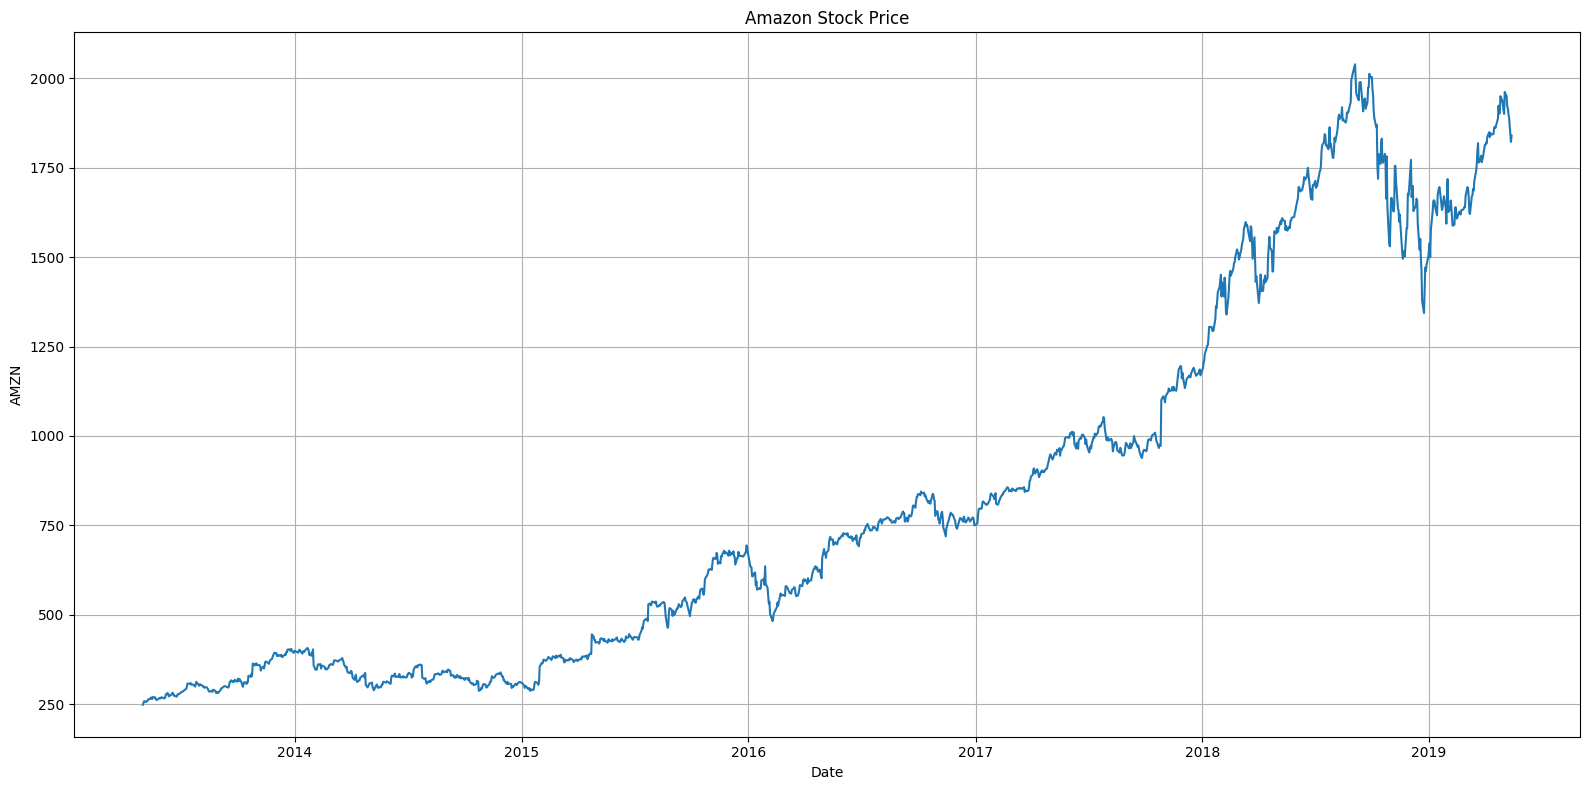

In [ ]:
ut.plot_data(data, "Amazon Stock Price", "Date", "AMZN")

### Generate Sliding Windows

In [ ]:
selected_value = data[target_column].values
window_data = {}
for days in output_days:
    X, y = ut.generate_sliding_windows(
        selected_value,
        input_days,
        days
        )
    window_data[days] = {
        "X" : X,
        "y" : y
    }

Input : 30 days | Output : 1 days | Windows: 1490
Input : 30 days | Output : 7 days | Windows: 1484
Input : 30 days | Output : 14 days | Windows: 1477


### Split Data

In [ ]:
train_test_data = ut.split_data(
    window_data,
    output_days,
    test_size,
    shuffle
)

### Data Scaling

In [ ]:
scaled_data = ut.scale_all_data(train_test_data)

### Train Regression Models

### Dense Deep Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
def generate_model():
    dense_model = Sequential()
    dense_model.add(Dense(8, input_shape = (30,), activation= "relu"))
    dense_model.add(Dense(70, activation= "relue"))
    dense_model.add(Dense(22, activation= "relu"))
    dense_model.add(Dense(17, activation= "relu"))
    dense_model.add(Dense(68, activation= "relu"))
    dense_model.add(Dense(60, activation= "relu"))
    dense_model.add(Dense(1))
    dense_model.summary()

    return dense_model